# SCOPE bi-modal demo --- full COAD slide

Histology + transcriptomics integration on the full colorectal Xenium slide (405,927 cells).


In [1]:
# --------------------------------------------------------------------------- #
# CONFIG -- everything tunable in one place.
# --------------------------------------------------------------------------- #
import sys, warnings
from pathlib import Path
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import tifffile
import torch
warnings.filterwarnings("ignore")

sys.path.insert(0, "/home/lihy/SCOPE_repo")
from scope import (SCOPE, SCOPETrainer, TrainConfig,
                   preprocess_histology, preprocess_transcriptomics)

# Foundation-model checkpoints. Swap for any timm-loadable HF ViT / NOVAE id.
HISTO_CHECKPOINT = "bioptimus/H0-mini"          # gated; needs HF_TOKEN
RNA_CHECKPOINT   = "MICS-Lab/novae-human-0"     # public
HF_TOKEN         = None                         # None -> use $HF_TOKEN env

# H&E preprocessing mode -- one of:
#   "resize56"       : crop 56x56 around cell, resize to 224x224, take CLS token
#   "gaussian_input" : crop 224x224, multiply pixels by 2D Gaussian, take token mean
#   "mask_token"     : crop 224x224, weight patch tokens by instance mask coverage
HE_MODE          = "resize56"

# Dataset paths + optional reference column for evaluation (bi-modal only).
ADATA_PATH    = "/home/lihy/spatch-genomics/COAD/adata_fullres.h5ad"
HE_PATH       = "/home/lihy/spatch-genomics/COAD/HE.tif"
REF_COL       = "annotation"


# Run + training parameters.
EPOCHS        = 200
BATCH_SIZE    = 1024
NUM_CLUSTERS  = 17
LEIDEN_RES    = 0.6           # single resolution used for the final eval
N_NEIGHBORS   = 10            # sc.pp.neighbors n_neighbors

DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR       = Path("/home/lihy/scope_reviewer_test/runs_demo_coad"); RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"device={DEVICE}   run_dir={RUN_DIR}")


device=cuda   run_dir=/home/lihy/scope_reviewer_test/runs_demo_coad


In [2]:
# --------------------------------------------------------------------------- #
# Load the full slide and run the per-modality preprocessors. H0-mini handles
# histology (mode chosen above); NOVAE handles transcriptomics; proteomics is
# arcsinh + percentile clip + z-score with no foundation model.
# --------------------------------------------------------------------------- #
adata = ad.read_h5ad(ADATA_PATH)
sp    = np.asarray(adata.obsm["spatial"], dtype=np.float32)
print(f"loaded adata: {adata.shape}")

coords_df = pd.DataFrame({"cell_id": adata.obs_names.astype(str).values,
                          "x": sp[:, 0], "y": sp[:, 1]})
he_full = tifffile.imread(HE_PATH)
print(f"loaded HE: {he_full.shape}")

he_feat  = preprocess_histology(he_image=he_full, coords=coords_df,
                                mode=HE_MODE,
                                checkpoint=HISTO_CHECKPOINT, hf_token=HF_TOKEN,
                                device=DEVICE)
del he_full
rna_feat = preprocess_transcriptomics(adata=adata, checkpoint=RNA_CHECKPOINT,
                                      device=DEVICE)
print(f"he_feat={he_feat.shape}  rna_feat={rna_feat.shape}")


loaded adata: (405927, 5001)


loaded HE: (36102, 49221, 3)


H&E preprocessing:   0%|          | 0/1586 [00:00<?, ?chunk/s]

[INFO] (novae.utils.build) Computing graph on 405,927 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)


[WARNING] (novae.model) On GPU, consider setting `num_workers` (e.g., 4 or 8) for better performance.


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Computing representations:   0%|          | 0/1578 [00:00<?, ?it/s]

he_feat=(405927, 768)  rna_feat=(405927, 64)


In [3]:
# --------------------------------------------------------------------------- #
# Build SCOPE (input dims auto-detected), train, and run mini-batched
# inference. The trainer shows a single horizontal tqdm bar across epochs
# with the running mean loss as postfix.
# --------------------------------------------------------------------------- #
inputs = {"histology": torch.from_numpy(he_feat), "transcriptomics": torch.from_numpy(rna_feat)}
coords = np.column_stack([coords_df["x"].values, coords_df["y"].values]).astype(np.float32)

model   = SCOPE.from_inputs(inputs)
trainer = SCOPETrainer(model, TrainConfig(
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=1e-3,
    w_align=1.0, w_recon=10.0, w_cluster=5.0,
    num_clusters=NUM_CLUSTERS, xbm_size=65536, device=DEVICE,
))
trainer.fit(inputs, coords)
embedding = trainer.inference(inputs, coords)

emb_adata = ad.AnnData(X=embedding, obs=adata.obs.copy(),
                       obsm={"spatial": coords})
emb_adata.write_h5ad(RUN_DIR / "embedding.h5ad")


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Early stopping at epoch 38.


Inference:   0%|          | 0/397 [00:00<?, ?it/s]

resolution=0.6  n_leiden_clusters=12  n_ref_labels=16
>>> ARI=0.157  NMI=0.260


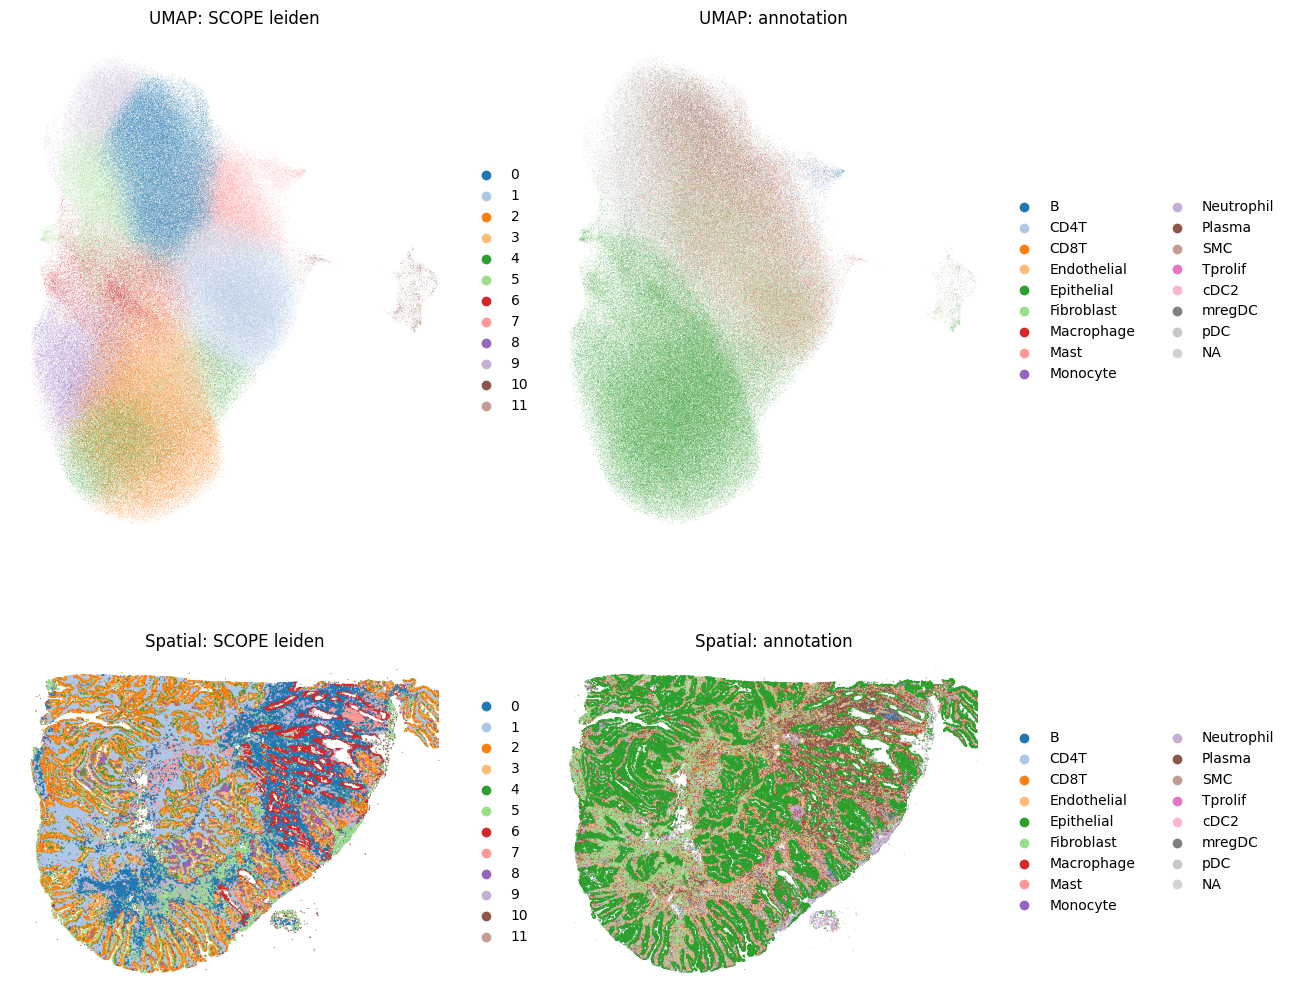

In [ ]:
# --------------------------------------------------------------------------- #
# Cluster the SCOPE embedding with Leiden and compare against the reference
# annotation. ARI/NMI are computed on the cells with non-missing labels; the
# four panels (UMAP | spatial, Leiden | reference) share a single palette per
# --------------------------------------------------------------------------- #
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.pp.neighbors(emb_adata, use_rep="X", n_neighbors=N_NEIGHBORS)
sc.tl.leiden(emb_adata, resolution=LEIDEN_RES, key_added="leiden")
sc.tl.umap(emb_adata)

ref  = emb_adata.obs[REF_COL].astype(str).values
keep = (ref != "nan") & (ref != "unassigned")
pred = emb_adata.obs["leiden"].astype(str).values
ari  = adjusted_rand_score(ref[keep], pred[keep])
nmi  = normalized_mutual_info_score(ref[keep], pred[keep])
print(f"resolution={LEIDEN_RES}  n_leiden_clusters={len(np.unique(pred))}  "
      f"n_ref_labels={len(np.unique(ref[keep]))}")
print(f">>> ARI={ari:.3f}  NMI={nmi:.3f}")

import matplotlib.pyplot as plt
for col in ("leiden", REF_COL):
    emb_adata.obs[col] = emb_adata.obs[col].astype("category")
    n = len(emb_adata.obs[col].cat.categories)
    cmap = plt.get_cmap("tab20")
    emb_adata.uns[f"{col}_colors"] = [cmap(i % cmap.N) for i in range(n)]

fig, ax = plt.subplots(2, 2, figsize=(13, 11))
sc.pl.umap(emb_adata, color="leiden", ax=ax[0, 0], show=False, frameon=False,
           title="UMAP: SCOPE leiden")
sc.pl.umap(emb_adata, color=REF_COL, ax=ax[0, 1], show=False, frameon=False,
           title=f"UMAP: {REF_COL}")
sc.pl.embedding(emb_adata, basis="spatial", color="leiden", ax=ax[1, 0],
                show=False, frameon=False, title="Spatial: SCOPE leiden",
                size=2.5)
ax[1, 0].invert_yaxis(); ax[1, 0].set_aspect("equal")
sc.pl.embedding(emb_adata, basis="spatial", color=REF_COL, ax=ax[1, 1],
                show=False, frameon=False, title=f"Spatial: {REF_COL}",
                size=2.5)
ax[1, 1].invert_yaxis(); ax[1, 1].set_aspect("equal")
plt.tight_layout(); plt.savefig(RUN_DIR / "panels.png", dpi=140, bbox_inches="tight")
plt.show()
